<h1 style="color:brown;">Linear Regression</h1>


---

<h2 style="color:Purple;">Imports</h2>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

---

<h2 style="color:Purple;">Exploring Data</h2>


<h3 style="color:green;">Load</h3>
Loaded & examined the data<br>
Checked for nulls and duplicates<br>


In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

<h3 style="color:green;">Clean</h3>
Encoded data using LabelEncoder<br>


In [7]:
categorical_cols = ['sex','smoker','region']

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


<h3 style="color:green;">Visualize</h3>
Added heatmap to find correlations<br>
Added scatterplot & histograms to identify outliers and visualize data<br>


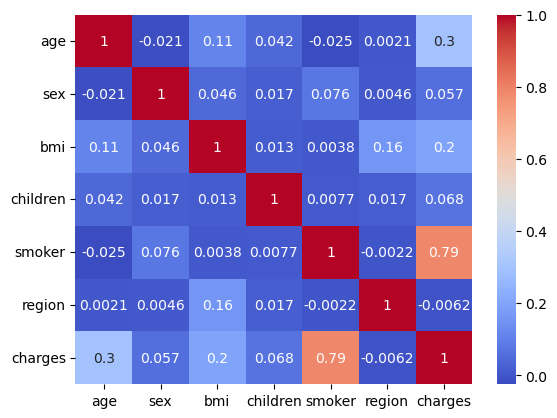

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

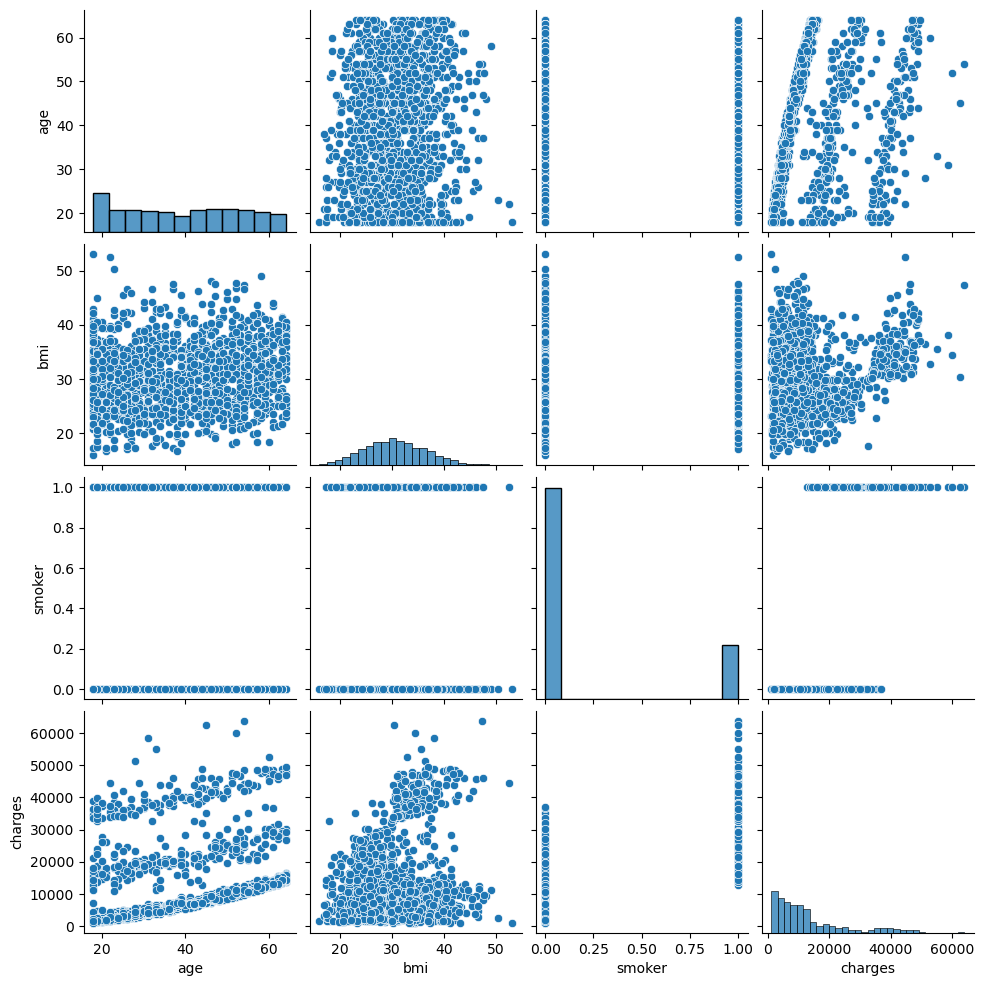

In [11]:
sns.pairplot(df[['age','bmi','smoker','charges']])
plt.show()

---

<h2 style="color:Purple;">Preprocessing</h2>


Split data into 80% training and 20% testing<br>
Scaled features<br>


In [12]:
X = df.drop("charges", axis = 1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

<h2 style="color:Purple;">Simple Linear Regression</h2>


Scaled only "smoker" feature for Simple LR<br>
Applied Linear Regression model<br>
Calculated R squared and MSE<br>
Plotted Smoker feature against Charges target and plotted the regression line<br>


In [14]:
scaler = StandardScaler()
X_train_smoker = scaler.fit_transform(X_train[['smoker']])
X_test_smoker = scaler.transform(X_test[['smoker']])

In [15]:
slr = LinearRegression()
slr.fit(X_train_smoker, y_train)

LinearRegression()

In [16]:
y_pred = slr.predict(X_test_smoker)

In [17]:
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.6602486589056527
MSE: 52745964.727526285


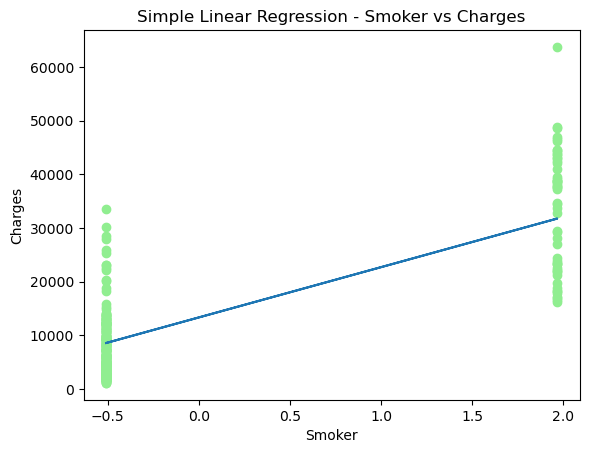

In [18]:
plt.scatter(X_test_smoker, y_test, color='lightgreen')
plt.plot(X_test_smoker, y_pred)
plt.title("Simple Linear Regression - Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

---

<h2 style="color:Purple;">Multiple Linear Regression</h2>


Applied Multiple LR model on splitted data from "preprocessing" section<br>
Calculated R squared and MSE<br>
Plotted Smoker feature against Charges target and plotted the regression line<br>


In [19]:
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

LinearRegression()

In [20]:
y_pred = mlr.predict(X_test_scaled)

In [21]:
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.7833463107364536
MSE: 33635210.43117845


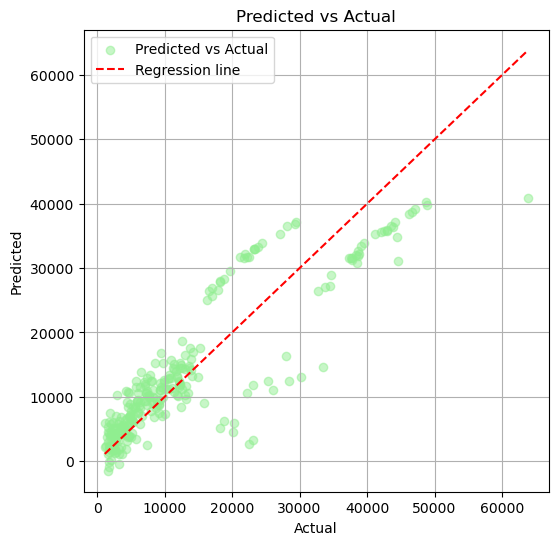

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='lightgreen', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Regression line')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

---

<h2 style="color:Purple;">Polynomial Regression</h2>


Selected Age feature against Charges target because "Smoker" is binary feature<br>
Scaled Age feature<br>
For each degree, transform data to degree then apply polynomial regression model<br>
Calculated R squared and MSE for each degree<br>
Plotted Age feature against Charges target and plotted the Polynomial Regression line for each degree<br>


In [23]:
X = df[['age']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Degree 2
R²: 0.11873673494547743
MSE: 136815004.0100132



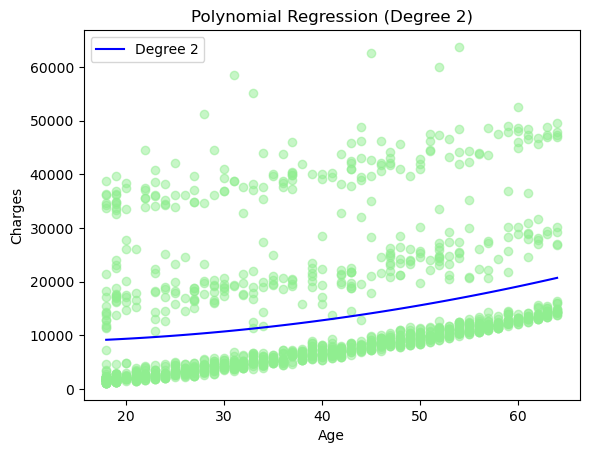

Degree 3
R²: 0.11854150943633013
MSE: 136845312.52266315



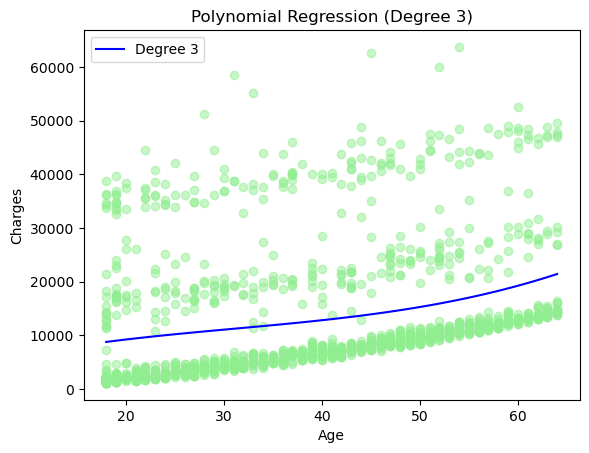

Degree 4
R²: 0.11920113570722513
MSE: 136742906.38084805



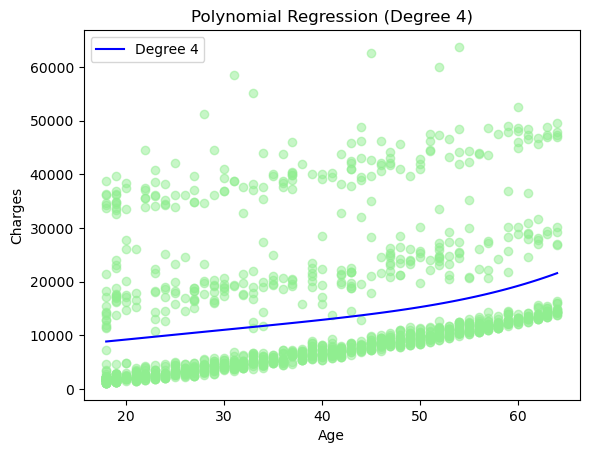

In [25]:
for degree in [2, 3, 4]:

    # Transform the scaled training and test data to include polynomial terms
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    prm = LinearRegression()
    prm.fit(X_train_poly, y_train)
    y_pred = prm.predict(X_test_poly)

    # R squared and MSE
    print(f"Degree {degree}")
    print("R²:", r2_score(y_test, y_pred))  # Coefficient of determination
    print("MSE:", mean_squared_error(y_test, y_pred))  # Mean squared error
    print()


    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    x_range_scaled = scaler.transform(x_range)
    x_range_poly = poly.transform(x_range_scaled)

    y_range_pred = prm.predict(x_range_poly)

# Visualizing
    plt.scatter(X, y, color='lightgreen', alpha=0.5) # Plotting original data
    plt.plot(x_range, y_range_pred, label=f'Degree {degree}', color='blue') # Plotting predicted

    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend()
    plt.show()

<h1 style="color:lightblue;">Linear Regression Summary</h1>


<br>The most correlated feature (smoker) turned to be a binary feature (two unique inputs only)...
<br>... so this feature was only used in Simple Linear Regression and not Polynomial Regression.
<br>
<br>Multiple Linear Regression (using all features) proved to be the most effective predictor between Polynomial and Single Linear Regression.
<br>
<br>Polynomial Regression, when used with "Age" feature (because it is the second most correlated), proved to be the worst predictor...
<br>... so increasing order of this model was ineffective.


<h1 style="color:brown;">Logistic Regression</h1>


---

<h2 style="color:Purple;">Imports</h2>


In [26]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

---

<h2 style="color:Purple;">Exploring Data</h2>


In [27]:
# importing data
data = pd.read_csv("loan_data.csv")
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [28]:
# checking duplicates, nulls, data Types and  Encode Categorical Variables
data = pd.read_csv("loan_data.csv")
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [29]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# Create X and making feature selection (execluding the last column and some column which is less related)
X = data.drop(["loan_status","person_gender","person_education","person_emp_exp","cb_person_cred_hist_length","person_age","loan_intent"], axis=1)

# Create y (the target column)
y = data["loan_status"]

# Check the head of the features DataFrame
X.head()

,person_income,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,71948.0,RENT,35000.0,16.02,0.49,561,No
1,12282.0,OWN,1000.0,11.14,0.08,504,Yes
2,12438.0,MORTGAGE,5500.0,12.87,0.44,635,No
3,79753.0,RENT,35000.0,15.23,0.44,675,No
4,66135.0,RENT,35000.0,14.27,0.53,586,No


---

<h2 style="color:Purple;">Preprocessing</h2>


In [31]:
#Scalling features

scaler = MinMaxScaler()

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X


,person_income,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,0.008891,RENT,1.000000,0.727023,0.742424,0.371739,No
1,0.000595,OWN,0.014493,0.392318,0.121212,0.247826,Yes
2,0.000617,MORTGAGE,0.144928,0.510974,0.666667,0.532609,No
3,0.009976,RENT,1.000000,0.672840,0.666667,0.619565,No
4,0.008082,RENT,1.000000,0.606996,0.803030,0.426087,No
...,...,...,...,...,...,...,...
44995,0.005557,RENT,0.420290,0.702332,0.469697,0.554348,No
44996,0.008036,RENT,0.246377,0.593278,0.212121,0.502174,No
44997,0.006804,RENT,0.065826,0.315501,0.075758,0.604348,No
44998,0.003499,RENT,0.333333,0.535665,0.545455,0.465217,No


In [32]:

# 2. Define the categorical features to transform
categorical_features = ["person_home_ownership","previous_loan_defaults_on_file"]

# 3. Create an instance of OneHotEncoder
one_hot = OneHotEncoder()

# 4. Create an instance of ColumnTransformer
transformer = ColumnTransformer([("one_hot", # name
                                  one_hot, # transformer
                                  categorical_features)], # columns to transform
                                  remainder="passthrough") # what to do with the rest of the columns? ("passthrough" = leave unchanged) 

# 5. Turn the categorical features into numbers (this will return an array-like sparse matrix, not a DataFrame)
transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.        , 0.        , 0.        , ..., 0.72702332, 0.74242424,
        0.37173913],
       [0.        , 0.        , 1.        , ..., 0.39231824, 0.12121212,
        0.24782609],
       [1.        , 0.        , 0.        , ..., 0.51097394, 0.66666667,
        0.5326087 ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.31550069, 0.07575758,
        0.60434783],
       [0.        , 0.        , 0.        , ..., 0.53566529, 0.54545455,
        0.46521739],
       [0.        , 0.        , 0.        , ..., 0.79766804, 0.1969697 ,
        0.5173913 ]])

---

<h2 style="color:Purple;">Logistic Regression</h2>


In [34]:
# Splitting the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36000, 11), (9000, 11), (36000,), (9000,))

In [35]:

model = LogisticRegression()

# Fit the model on the numerical data (this errored before since our data wasn't fully numeric)
model.fit(X_train, y_train)

LogisticRegression()

In [36]:
# Score the model (returns r^2 metric by default, also called coefficient of determination, higher is better)
model.score(X_test, y_test)

0.8923333333333333

In [37]:
y_pred = model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[6523  465]
 [ 504 1508]]


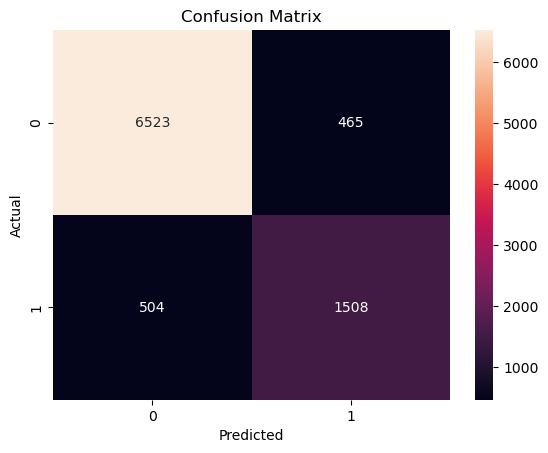

In [38]:

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
accuracy = accuracy_score(y_test, y_pred)

In [40]:
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.89
